# **Dengue Detection**

### **Problem Statement**
-  This project understands how the Dengue (test scores) is affected by other variables such as age, gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label.                

### **Import Data and Required Packages**

In [284]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Import the CSV Data as Pandas DataFrame

In [285]:
data = pd.read_csv("G:\\dengue dataset\\Dengue_diseases_dataset_modified (1).csv")

### Show Top 5 Records

In [286]:
data.head(5)

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


### Shape of the dataset

In [287]:
data.shape

(989, 9)

### **Dataset information**
-   age: Age of the patient
-    gender: Male or Female
-    hemoglobin_g_dl: Hemoglobin level (g/dL)
-    wbc_count: White blood cell count
-    differential_count: Differential WBC count
-    rbc_count: Red blood cell count
-    platelet_count: Platelet count
-    platelet_distribution_width: Platelet size variation (PDW)
-    dengue_label: Target variable (0 = No Dengue, 1 = Dengue)


### Check Missing values

In [288]:
data.isna().sum() /len(data)*100

age                            0.000000
gender                         0.000000
hemoglobin_g_dl                0.000000
wbc_count                      2.426694
differential_count             0.000000
rbc_count                      0.000000
platelet_count                 1.617796
platelet_distribution_width    1.921132
dengue_label                   0.000000
dtype: float64

- There are missing values which are lesser than 5% so where are droping them

In [289]:
data = data.dropna(axis=0)

### Check Duplicates

In [290]:
data.duplicated().sum()

np.int64(0)

- There are no duplicates 

### Check data types

In [291]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 931 entries, 0 to 988
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          931 non-null    int64  
 1   gender                       931 non-null    object 
 2   hemoglobin_g_dl              931 non-null    float64
 3   wbc_count                    931 non-null    float64
 4   differential_count           931 non-null    int64  
 5   rbc_count                    931 non-null    int64  
 6   platelet_count               931 non-null    float64
 7   platelet_distribution_width  931 non-null    float64
 8   dengue_label                 931 non-null    int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 72.7+ KB


### Checking the number of unique values of each column

In [292]:
data.nunique()

age                             99
gender                           3
hemoglobin_g_dl                 53
wbc_count                       73
differential_count               2
rbc_count                        2
platelet_count                 346
platelet_distribution_width    239
dengue_label                     2
dtype: int64

### Check statistics of data set

In [293]:
data.describe()

,age,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
count,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000,931.000000
mean,42.452202,13.728786,4336.305048,0.937701,0.938776,114396.062299,22.970354,0.649839
std,20.884542,1.479163,2349.773013,0.241827,0.239870,89113.865754,14.871438,0.477277
min,3.000000,11.000000,2000.000000,0.000000,0.000000,10000.000000,1.000000,0.000000
25%,27.000000,12.600000,2600.000000,1.000000,1.000000,46000.000000,14.000000,0.000000
50%,41.000000,13.700000,3200.000000,1.000000,1.000000,93000.000000,17.900000,1.000000
75%,55.000000,15.000000,6200.000000,1.000000,1.000000,162500.000000,28.800000,1.000000
max,120.000000,25.000000,10900.000000,1.000000,1.000000,500000.000000,215.000000,1.000000


* Insights
  - the count of all columns are equal
  - the means are different for different columns
  - the standard deviation are also different for different colums
  - some columns contains outilers

###  Exploring Data

In [294]:
data.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


In [295]:
print("Categories in 'gender' variable:     ",end=" " )
print(data['gender'].unique())


Categories in 'gender' variable:      ['Male' 'Female' 'Child']


In [296]:
numerical_columns = data.select_dtypes(include=['int64','float64']).columns
categorical_columns= data.select_dtypes(include=['object']).columns
print(numerical_columns)
print(categorical_columns)

Index(['age', 'hemoglobin_g_dl', 'wbc_count', 'differential_count',
       'rbc_count', 'platelet_count', 'platelet_distribution_width',
       'dengue_label'],
      dtype='object')
Index(['gender'], dtype='object')


### Adding columns "Platelet-to-WBC Ratio"

In [297]:
data['Platelet-to-WBC Ratio']  = data['platelet_count'] / data ['wbc_count']
data

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label,Platelet-to-WBC Ratio
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1,28.181818
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1,5.666667
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1,5.757576
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1,8.285714
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1,9.677419
...,...,...,...,...,...,...,...,...,...,...
984,27,Female,11.6,9400.0,1,1,400000.0,39.9,0,42.553191
985,19,Female,15.8,7400.0,1,1,320560.0,56.0,0,43.318919
986,54,Female,11.9,7500.0,1,1,345000.0,44.4,0,46.000000
987,34,Male,14.6,9500.0,1,1,326000.0,41.9,0,34.315789


- added new feature 'platelet-to-WBC Ratio'
-   Dengue often gets if less Platelet-to-WBC Ratio

### **Exploring Data ( Visualization )**

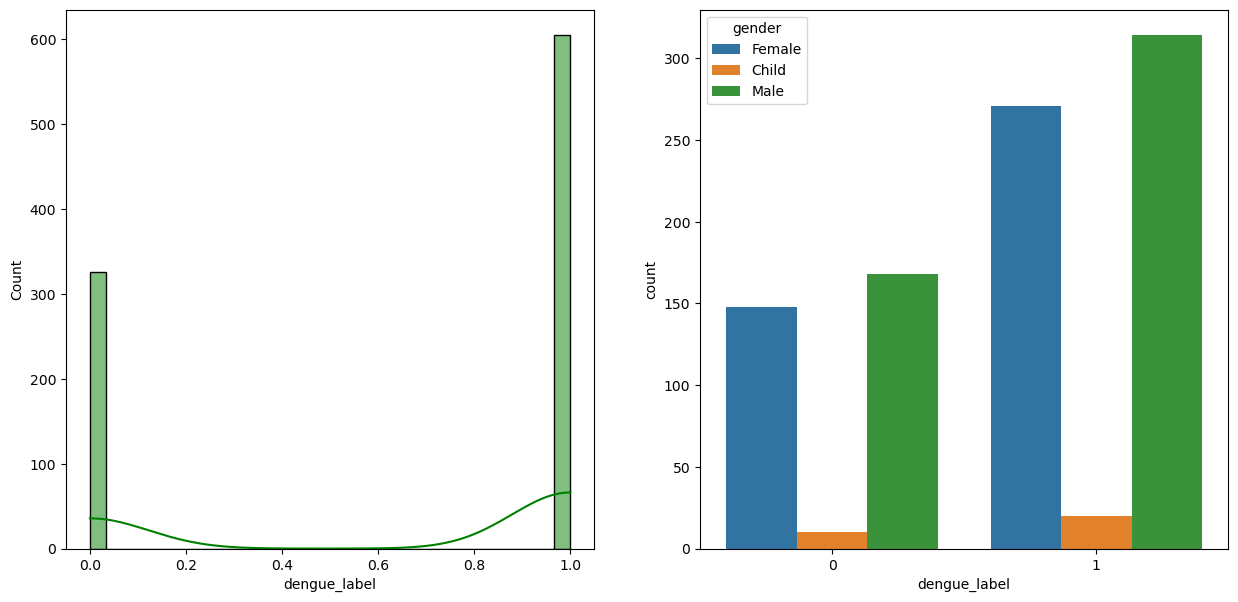

In [298]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=data,x='dengue_label',bins=30,kde=True,color='g')
plt.subplot(122)
sns.countplot(data=data,x='dengue_label',hue='gender')
plt.show()



- Insight
  - from plot 1 we observed that there more number of dengue occured
  - from plot 2 we observed that male are affected more compared to female and child

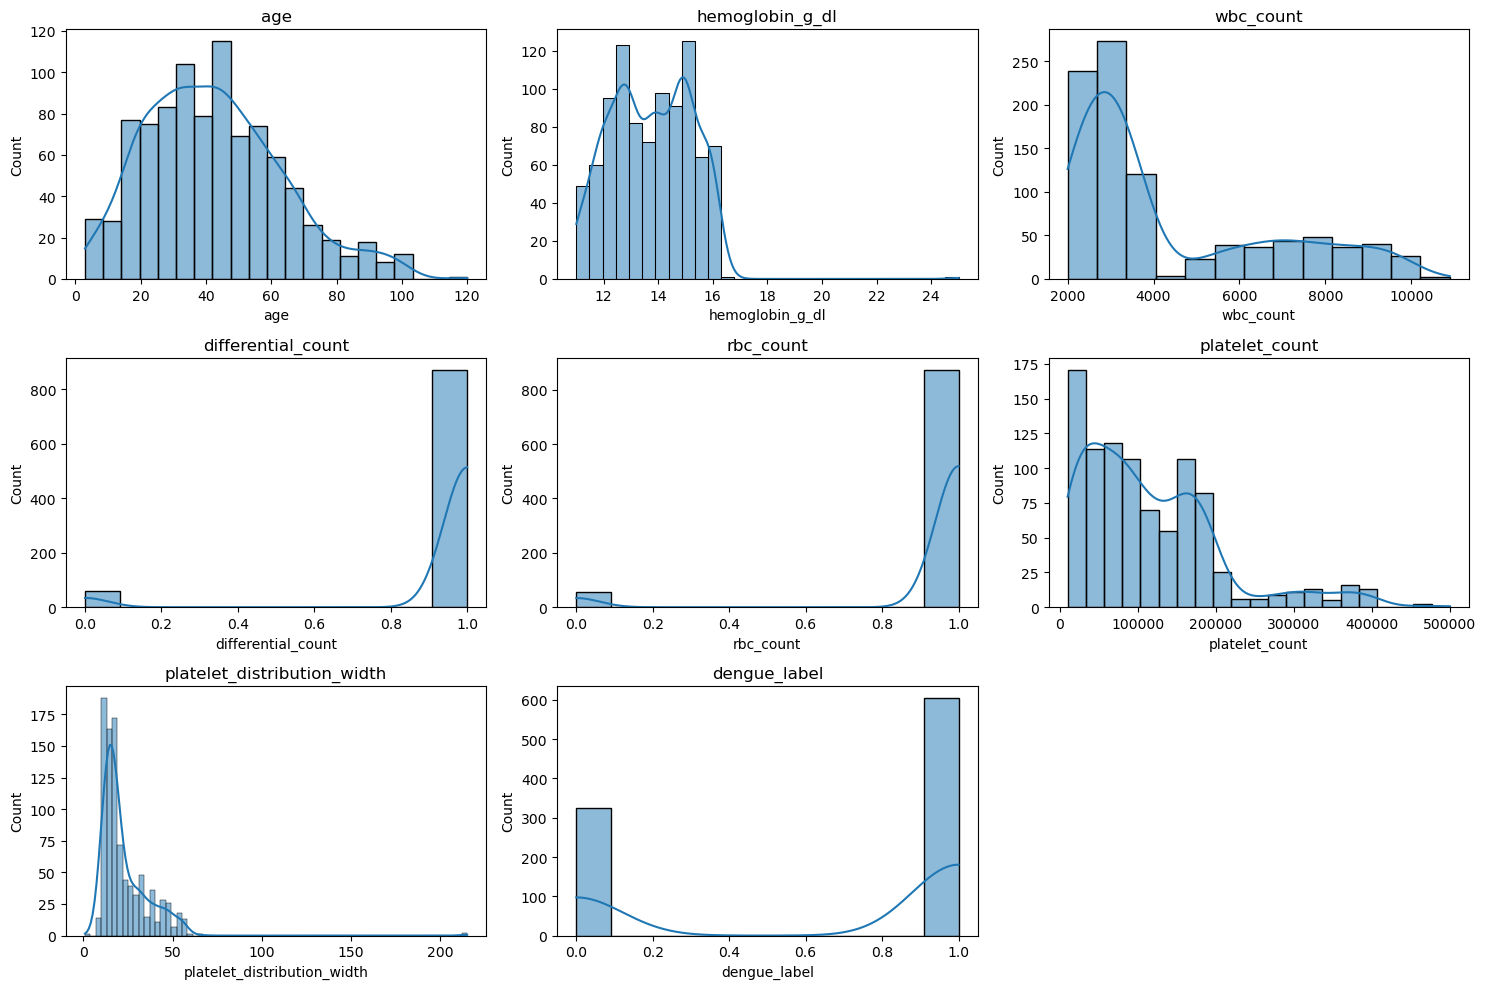

In [299]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

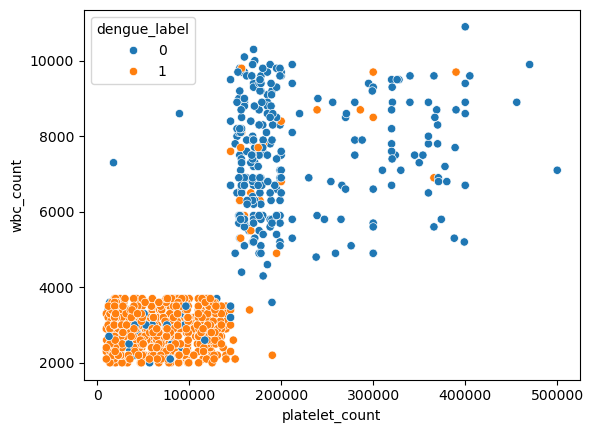

In [300]:
sns.scatterplot(x='platelet_count', y='wbc_count',hue='dengue_label', data=data)
plt.show()

- Insights
  - Dengue occurrence is strongly associated with low platelet count and low WBC .

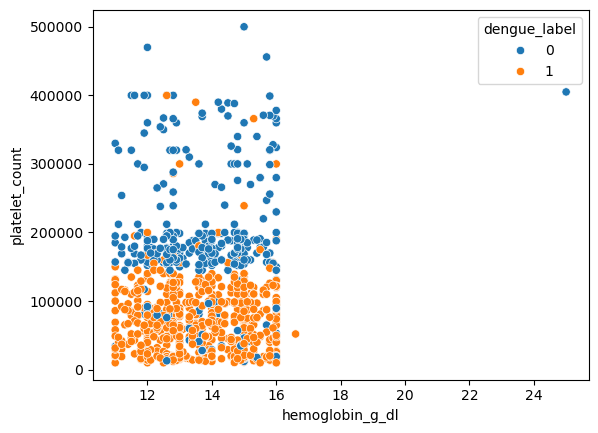

In [301]:
sns.scatterplot(x='hemoglobin_g_dl', y='platelet_count',hue='dengue_label', data=data)
plt.show()

- Insights
  - Dengue occurrence is strongly associated with low platelet count while hemoglobin remains relatively stable and has limited predictive power.

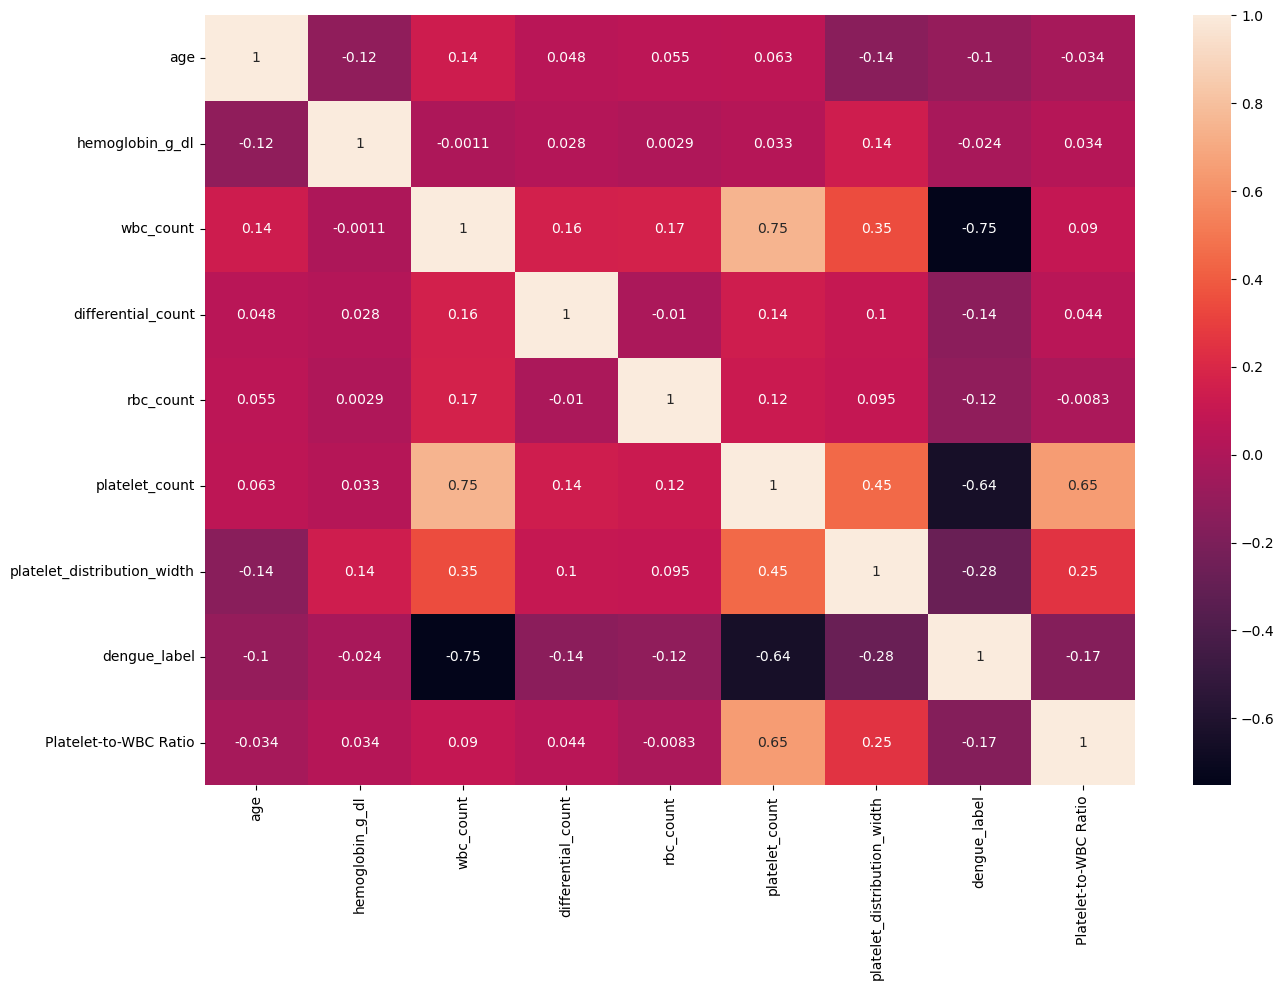

In [302]:
plt.figure(figsize=(15, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

- Insights
  - WBC count (−0.75) and platelet count (−0.64) show strong negative correlations with dengue, indicating that lower values are associated with higher dengue occurrence.

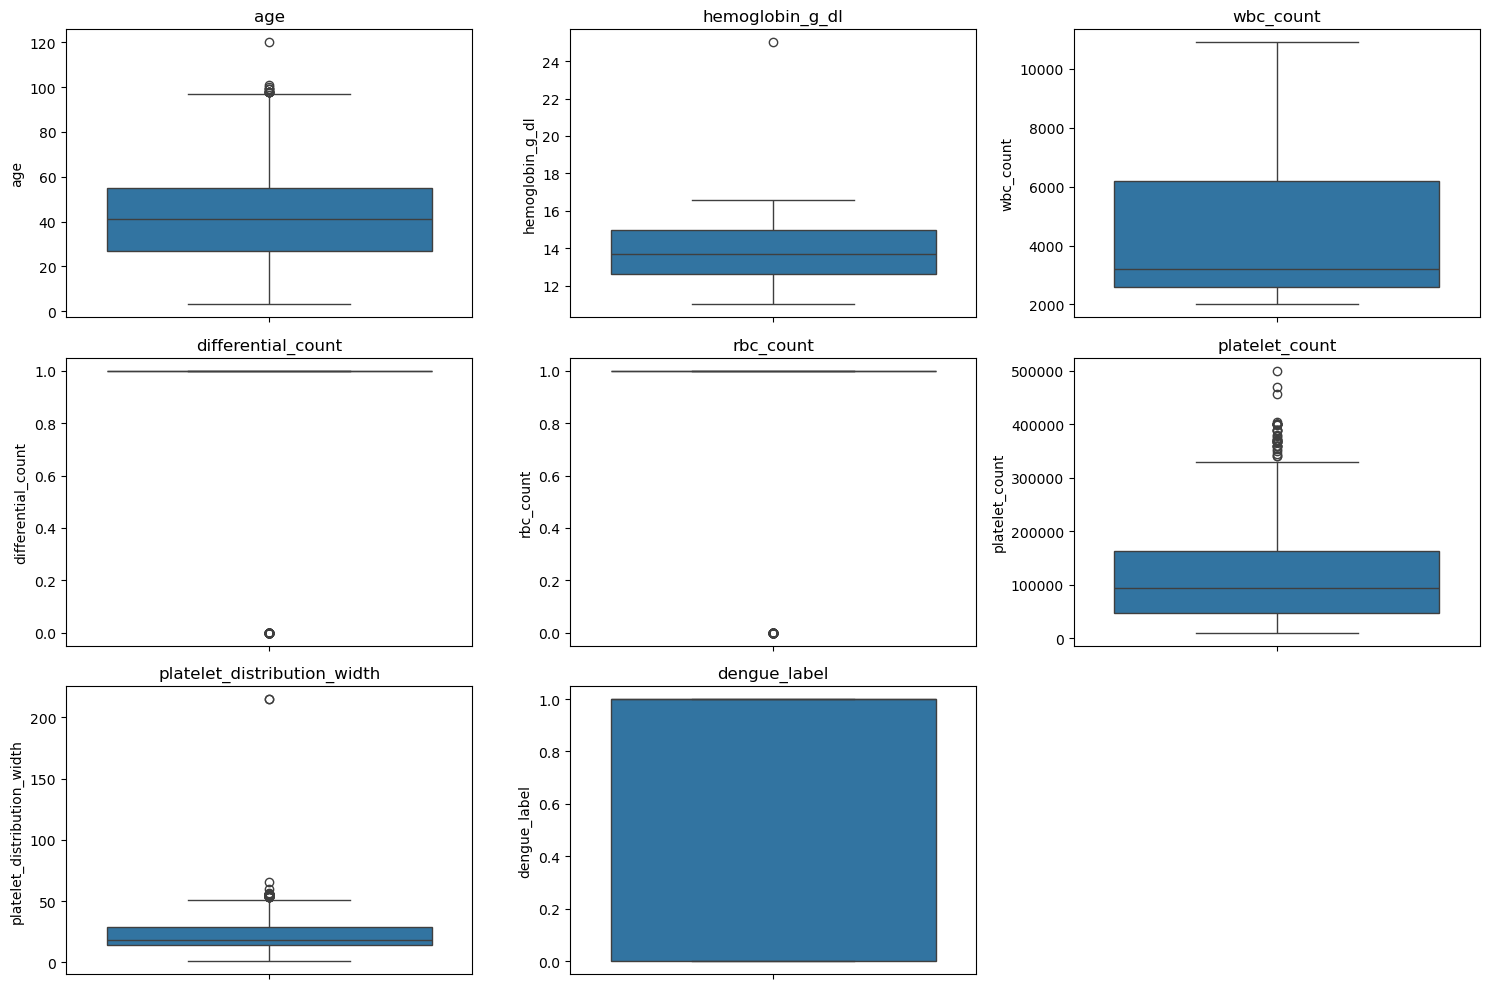

In [303]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_columns):
    plt.subplot(3, 3, i + 1) 
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

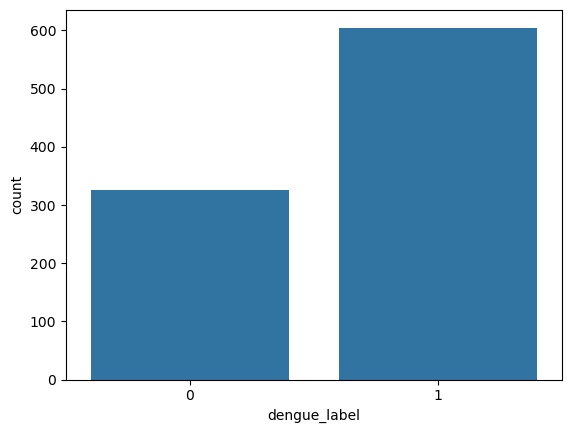

In [304]:
sns.countplot(data=data,x='dengue_label')
plt.show()

In [305]:
data['dengue_label'].value_counts(normalize=True)


dengue_label
1    0.649839
0    0.350161
Name: proportion, dtype: float64

- Insights
  - The target variable shows a moderate class imbalance, with approximately 65% dengue cases and 35% non-dengue cases. While not severely imbalanced, this distribution may introduce slight bias toward the majority class and should be considered during model evaluation.

## **Machine Learning**

In [306]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.preprocessing import StandardScaler,OneHotEncoder,RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,ConfusionMatrixDisplay,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import warnings

### Show Top 5 Records

In [307]:
data.head(5)

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,dengue_label,Platelet-to-WBC Ratio
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1,28.181818
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1,5.666667
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1,5.757576
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1,8.285714
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1,9.677419


### Preparing X and Y variables

In [308]:
X = data.drop(columns=['dengue_label'],axis=1)

In [309]:
X.head()

,age,gender,hemoglobin_g_dl,wbc_count,differential_count,rbc_count,platelet_count,platelet_distribution_width,Platelet-to-WBC Ratio
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,28.181818
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,5.666667
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,5.757576
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,8.285714
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,9.677419


In [310]:
y = data['dengue_label']

In [311]:
y

0      1
1      1
2      1
3      1
4      1
      ..
984    0
985    0
986    0
987    0
988    0
Name: dengue_label, Length: 931, dtype: int64

In [312]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(744, 9)
(187, 9)
(744,)
(187,)


In [313]:
num_outliers_col = ['age', 'platelet_count', 'hemoglobin_g_dl']

num_col = X.select_dtypes(include=['int64', 'float64']).drop(columns=num_outliers_col).columns

cat_col = X.select_dtypes(include=['object']).columns

print(num_outliers_col)
print('************************')
print(num_col)
print('************************')
print(cat_col)

['age', 'platelet_count', 'hemoglobin_g_dl']
************************
Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')
************************
Index(['gender'], dtype='object')


### pipeline

In [314]:
num_pipeline = Pipeline([
    ('Standard Scaler',StandardScaler())
])
numerical_outilers_pipeline = Pipeline([
    ('Robust Scaler',RobustScaler())
])
cat_pipeline = Pipeline([
    ('Scaler_used',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
])

### Column Transformer

In [315]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numerical',num_pipeline,num_col),
        ('num_outilers_distributed',numerical_outilers_pipeline,num_outliers_col),
        ('categorical',cat_pipeline,cat_col)
    ]
)

### KNN Classifier

In [316]:
model_1 = KNeighborsClassifier()

In [317]:
knn_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('Knn Classifier',model_1)
])

In [318]:
knn_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('Knn Classifier', KNeighborsClassifier())])

In [319]:
y_test_pred_knn = knn_pipeline.predict(X_test)
y_train_pred_knn = knn_pipeline.predict(X_train)

In [320]:
testing_acc_score = accuracy_score(y_test,y_test_pred_knn)
training_acc_score = accuracy_score(y_train,y_train_pred_knn)
testing_f1_score = f1_score(y_test,y_test_pred_knn,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_knn,average='macro')
print('KNN-Classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

KNN-Classifier
***********************************
Testing-f1-score: 0.8994146495807624
Training-f1-score: 0.9080385239640049
Testing-accuracy: 0.9090909090909091
Training-accuracy: 0.918010752688172


<Figure size 1500x1000 with 0 Axes>

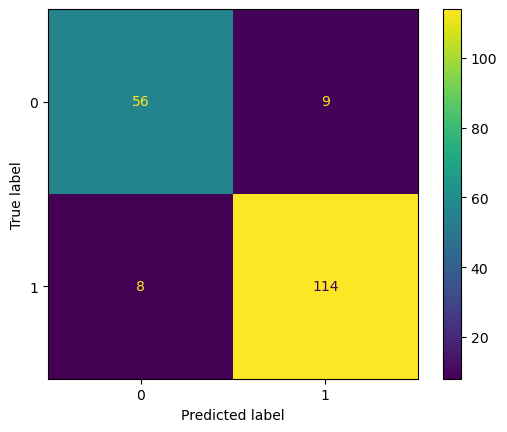

In [321]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_knn)
plt.show()

In [322]:
print(classification_report(y_test, y_test_pred_knn))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        65
           1       0.93      0.93      0.93       122

    accuracy                           0.91       187
   macro avg       0.90      0.90      0.90       187
weighted avg       0.91      0.91      0.91       187



### Decision Tree Classifier

In [323]:
model_2 = DecisionTreeClassifier()

In [324]:
decision_tree_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('decision tree',model_2)
])

In [325]:
decision_tree_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('decision tree', DecisionTreeClassifier())])

In [326]:
y_test_pred_dt = decision_tree_pipeline.predict(X_test)
y_train_pred_dt = decision_tree_pipeline.predict(X_train)

In [327]:
testing_acc_score = accuracy_score(y_test,y_test_pred_dt)
training_acc_score = accuracy_score(y_train,y_train_pred_dt)
testing_f1_score = f1_score(y_test,y_test_pred_dt,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_dt,average='macro')
print('Decision Tree Classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

Decision Tree Classifier
***********************************
Testing-f1-score: 0.7551190476190477
Training-f1-score: 1.0
Testing-accuracy: 0.7647058823529411
Training-accuracy: 1.0


<Figure size 1500x1000 with 0 Axes>

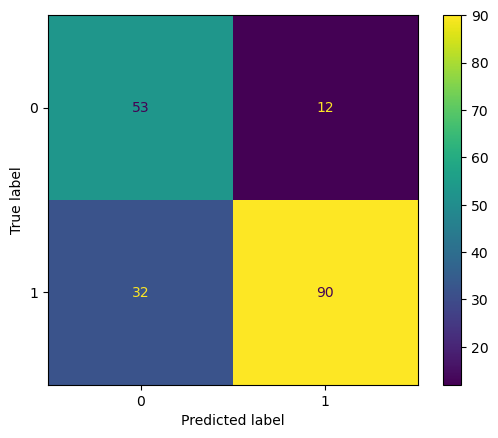

In [328]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_dt)
plt.show()

In [329]:
print(classification_report(y_test, y_test_pred_dt))

              precision    recall  f1-score   support

           0       0.62      0.82      0.71        65
           1       0.88      0.74      0.80       122

    accuracy                           0.76       187
   macro avg       0.75      0.78      0.76       187
weighted avg       0.79      0.76      0.77       187



### Random Forest Classifer

In [330]:
model_3 = RandomForestClassifier()

In [331]:
random_forest_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('random forest classifer',model_3)
])

In [332]:
random_forest_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('random forest classifer', RandomForestClassifier())])

In [333]:
y_test_pred_rf = random_forest_pipeline.predict(X_test)
y_train_pred_rf = random_forest_pipeline.predict(X_train)

In [334]:
testing_acc_score = accuracy_score(y_test,y_test_pred_rf)
training_acc_score = accuracy_score(y_train,y_train_pred_rf)
testing_f1_score = f1_score(y_test,y_test_pred_rf,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_rf,average='macro')
print('Random Forest Classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

Random Forest Classifier
***********************************
Testing-f1-score: 0.8986579106761452
Training-f1-score: 1.0
Testing-accuracy: 0.9090909090909091
Training-accuracy: 1.0


<Figure size 1500x1000 with 0 Axes>

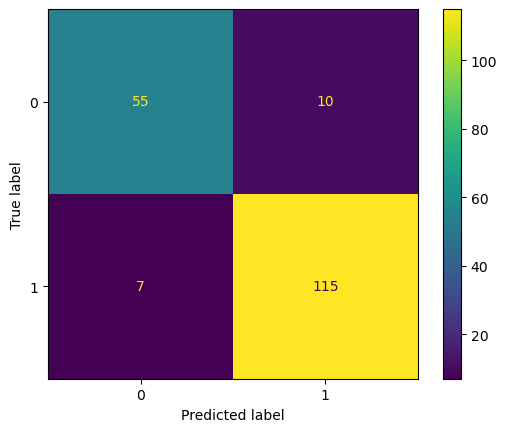

In [335]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_rf)
plt.show()

In [336]:
print(classification_report(y_test, y_test_pred_rf))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        65
           1       0.92      0.94      0.93       122

    accuracy                           0.91       187
   macro avg       0.90      0.89      0.90       187
weighted avg       0.91      0.91      0.91       187



### AdaBoost Classifier

In [337]:
model_4 = AdaBoostClassifier()

In [338]:
adaboost_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('ada boost classifier',model_4)
])

In [339]:
adaboost_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('ada boost classifier', AdaBoostClassifier())])

In [340]:
y_test_pred_ada = adaboost_pipeline.predict(X_test)
y_train_pred_ada = adaboost_pipeline.predict(X_train)

In [341]:
testing_acc_score = accuracy_score(y_test,y_test_pred_ada)
training_acc_score = accuracy_score(y_train,y_train_pred_ada)
testing_f1_score = f1_score(y_test,y_test_pred_rf,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_rf,average='macro')
print('Ada Boost Classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

Ada Boost Classifier
***********************************
Testing-f1-score: 0.8986579106761452
Training-f1-score: 1.0
Testing-accuracy: 0.9090909090909091
Training-accuracy: 0.9193548387096774


<Figure size 1500x1000 with 0 Axes>

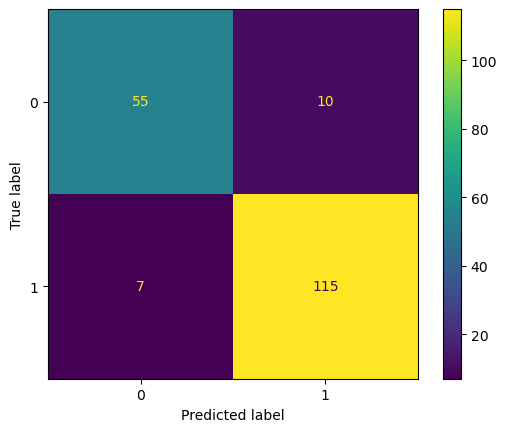

In [342]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_ada)
plt.show()

In [343]:
print(classification_report(y_test, y_test_pred_ada))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        65
           1       0.92      0.94      0.93       122

    accuracy                           0.91       187
   macro avg       0.90      0.89      0.90       187
weighted avg       0.91      0.91      0.91       187



### SVC

In [344]:
model_5 = SVC()

In [345]:
svc_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('SVC',model_5)
])

In [346]:
svc_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('SVC', SVC())])

In [347]:
y_test_pred_svc = svc_pipeline.predict(X_test)
y_train_pred_svc = svc_pipeline.predict(X_train)

In [348]:
testing_acc_score = accuracy_score(y_test,y_test_pred_svc)
training_acc_score = accuracy_score(y_train,y_train_pred_svc)
testing_f1_score = f1_score(y_test,y_test_pred_svc,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_svc,average='macro')
print('SVC Classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

SVC Classifier
***********************************
Testing-f1-score: 0.8922811059907834
Training-f1-score: 0.909456005841548
Testing-accuracy: 0.9037433155080213
Training-accuracy: 0.9193548387096774


<Figure size 1500x1000 with 0 Axes>

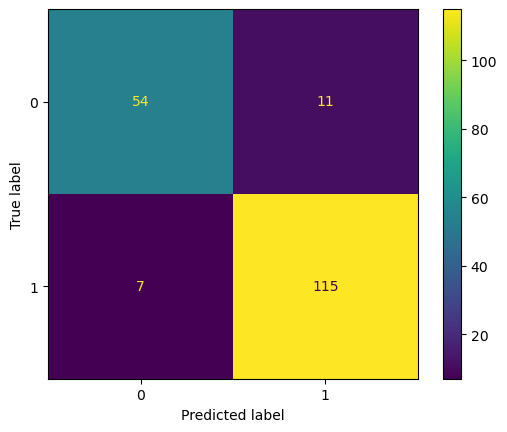

In [349]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_svc)
plt.show()

In [350]:
print(classification_report(y_test, y_test_pred_svc))

              precision    recall  f1-score   support

           0       0.89      0.83      0.86        65
           1       0.91      0.94      0.93       122

    accuracy                           0.90       187
   macro avg       0.90      0.89      0.89       187
weighted avg       0.90      0.90      0.90       187



### Logstic Regression

In [351]:
model_6 = LogisticRegression()

In [352]:
logistic_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('logistic regression',model_6)
])

In [353]:
logistic_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'platelet_count',
                                                   'hemoglobin_g_dl']),
                                                 ('categorical',
                                                  Pipeline(steps=[('Scaler_used',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender'], dtype='object'))])),
                ('logistic regression', LogisticRegression())])

In [354]:
y_test_pred_logistic = logistic_pipeline.predict(X_test)
y_train_pred_logistic = logistic_pipeline.predict(X_train)

In [355]:
testing_acc_score = accuracy_score(y_test,y_test_pred_logistic)
training_acc_score = accuracy_score(y_train,y_train_pred_logistic)
testing_f1_score = f1_score(y_test,y_test_pred_logistic,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_logistic,average='macro')
print('Logistic Regression')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

Logistic Regression
***********************************
Testing-f1-score: 0.8986579106761452
Training-f1-score: 0.9060598408263345
Testing-accuracy: 0.9090909090909091
Training-accuracy: 0.9166666666666666


<Figure size 1500x1000 with 0 Axes>

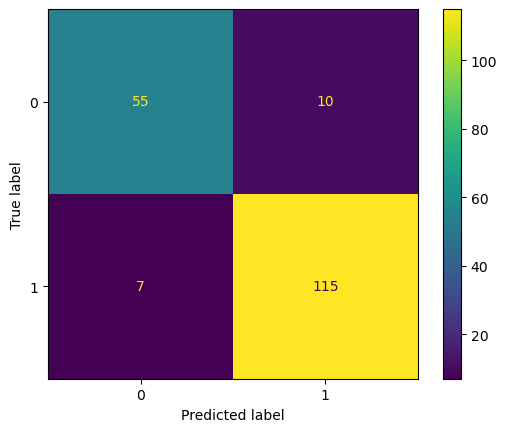

In [356]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_logistic)
plt.show()

In [357]:
print(classification_report(y_test, y_test_pred_logistic))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        65
           1       0.92      0.94      0.93       122

    accuracy                           0.91       187
   macro avg       0.90      0.89      0.90       187
weighted avg       0.91      0.91      0.91       187



### Xg boost Classifier

In [358]:
model_7 = XGBClassifier()

In [359]:
XGB_pipeline = Pipeline(steps=[
    ('preprocessing',preprocessor),
    ('XGB classifier',model_7)
])

In [360]:
XGB_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('Standard '
                                                                   'Scaler',
                                                                   StandardScaler())]),
                                                  Index(['wbc_count', 'differential_count', 'rbc_count',
       'platelet_distribution_width', 'Platelet-to-WBC Ratio'],
      dtype='object')),
                                                 ('num_outilers_distributed',
                                                  Pipeline(steps=[('Robust '
                                                                   'Scaler',
                                                                   RobustScaler())]),
                                                  ['age', 'plate...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [361]:
y_test_pred_XGB = XGB_pipeline.predict(X_test)
y_train_pred_XGB = XGB_pipeline.predict(X_train)

In [362]:
testing_acc_score = accuracy_score(y_test,y_test_pred_XGB)
training_acc_score = accuracy_score(y_train,y_train_pred_XGB)
testing_f1_score = f1_score(y_test,y_test_pred_XGB,average='macro')
training_f1_score = f1_score(y_train,y_train_pred_logistic,average='macro')
print('XGB classifier')
print('***********************************')
print('Testing-f1-score:',testing_f1_score)
print('Training-f1-score:',training_f1_score)
print('Testing-accuracy:',testing_acc_score)
print('Training-accuracy:',training_acc_score)

XGB classifier
***********************************
Testing-f1-score: 0.8712121212121212
Training-f1-score: 0.9060598408263345
Testing-accuracy: 0.8823529411764706
Training-accuracy: 1.0


<Figure size 1500x1000 with 0 Axes>

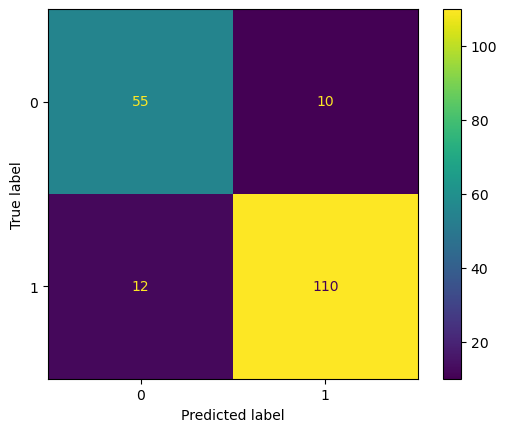

In [363]:
plt.figure(figsize=(15,10))
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_XGB)
plt.show()

In [364]:
print(classification_report(y_test, y_test_pred_XGB))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83        65
           1       0.92      0.90      0.91       122

    accuracy                           0.88       187
   macro avg       0.87      0.87      0.87       187
weighted avg       0.88      0.88      0.88       187



In [365]:
import pandas as pd

data = [
    ['KNN', 0.9180, 0.9091, 0.9080, 0.8994],
    ['Decision Tree', 1.0000, 0.7807, 1.0000, 0.7679],
    ['Random Forest', 1.0000, 0.9091, 1.0000, 0.8987],
    ['AdaBoost', 0.9194, 0.9091, 1.0000, 0.8987],
    ['SVC', 0.9194, 0.9037, 0.9095, 0.8923],
    ['Logistic Regression', 0.9167, 0.9091, 0.9061, 0.8987],
    ['XGBoost', 1.0000, 0.8824, 0.9061, 0.8712]
]

df = pd.DataFrame(data, columns=[
    'Model', 'Train Accuracy', 'Test Accuracy', 'Train F1', 'Test F1'
])

In [366]:
df = df.sort_values(by='Test F1', ascending=False).reset_index(drop=True)

In [367]:
df

,Model,Train Accuracy,Test Accuracy,Train F1,Test F1
0,KNN,0.9180,0.9091,0.9080,0.8994
1,Random Forest,1.0000,0.9091,1.0000,0.8987
2,AdaBoost,0.9194,0.9091,1.0000,0.8987
3,Logistic Regression,0.9167,0.9091,0.9061,0.8987
4,SVC,0.9194,0.9037,0.9095,0.8923
5,XGBoost,1.0000,0.8824,0.9061,0.8712
6,Decision Tree,1.0000,0.7807,1.0000,0.7679


- Insights
  - from above dataframe logistic regression , knn , svc has performed well

### Hyperparameter turining

### KNN classifier Hyperparameter turning

In [368]:
param_grid = {
    'Knn Classifier__n_neighbors': [3, 5, 7, 9, 10, 11],
    'Knn Classifier__metric': ['euclidean', 'minkowski'],
    'Knn Classifier__weights': ['uniform', 'distance']
}

grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.9064584043635528
Best params: {'Knn Classifier__metric': 'euclidean', 'Knn Classifier__n_neighbors': 10, 'Knn Classifier__weights': 'uniform'}


### svc hyperparameter-tuning

In [369]:
param_grid = [
    # Linear kernel
    {
        'SVC__kernel': ['linear'],
        'SVC__C': [0.1, 1, 10, 100]
    },
    # RBF kernel
    {
        'SVC__kernel': ['rbf'],
        'SVC__C': [0.1, 1, 10, 100],
        'SVC__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
]

# Step 4: GridSearchCV
grid = GridSearchCV(
    estimator=svc_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# Step 5: Fit
grid.fit(X_train, y_train)

# Step 6: Results
print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.9076648866674848
Best params: {'SVC__C': 1, 'SVC__gamma': 'auto', 'SVC__kernel': 'rbf'}


### Logistic Regression Hyperparameter -Turning

In [370]:
param_grid = {
    'logistic regression__C': [0.01, 0.1, 1, 10, 100],
    'logistic regression__penalty': ['l2'],  # safe default
    'logistic regression__solver': ['lbfgs', 'liblinear']
}

grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best score:", grid.best_score_)
print("Best params:", grid.best_params_)

Best score: 0.9059854582383577
Best params: {'logistic regression__C': 1, 'logistic regression__penalty': 'l2', 'logistic regression__solver': 'lbfgs'}


In [371]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        65
           1       0.92      0.94      0.93       122

    accuracy                           0.91       187
   macro avg       0.90      0.89      0.90       187
weighted avg       0.91      0.91      0.91       187



In [372]:
import pickle

# Best pipeline from GridSearch
best_pipeline = grid.best_estimator_

# Save
with open("best_logistic_model.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)

print("Model saved successfully ✅")

Model saved successfully ✅


In [373]:
import joblib
print(joblib.__version__)

1.4.2


In [374]:
import sklearn
print(sklearn.__version__)

1.6.1
